<a href="https://colab.research.google.com/github/SoneyBun/Reskaiue/blob/main/reskaiue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

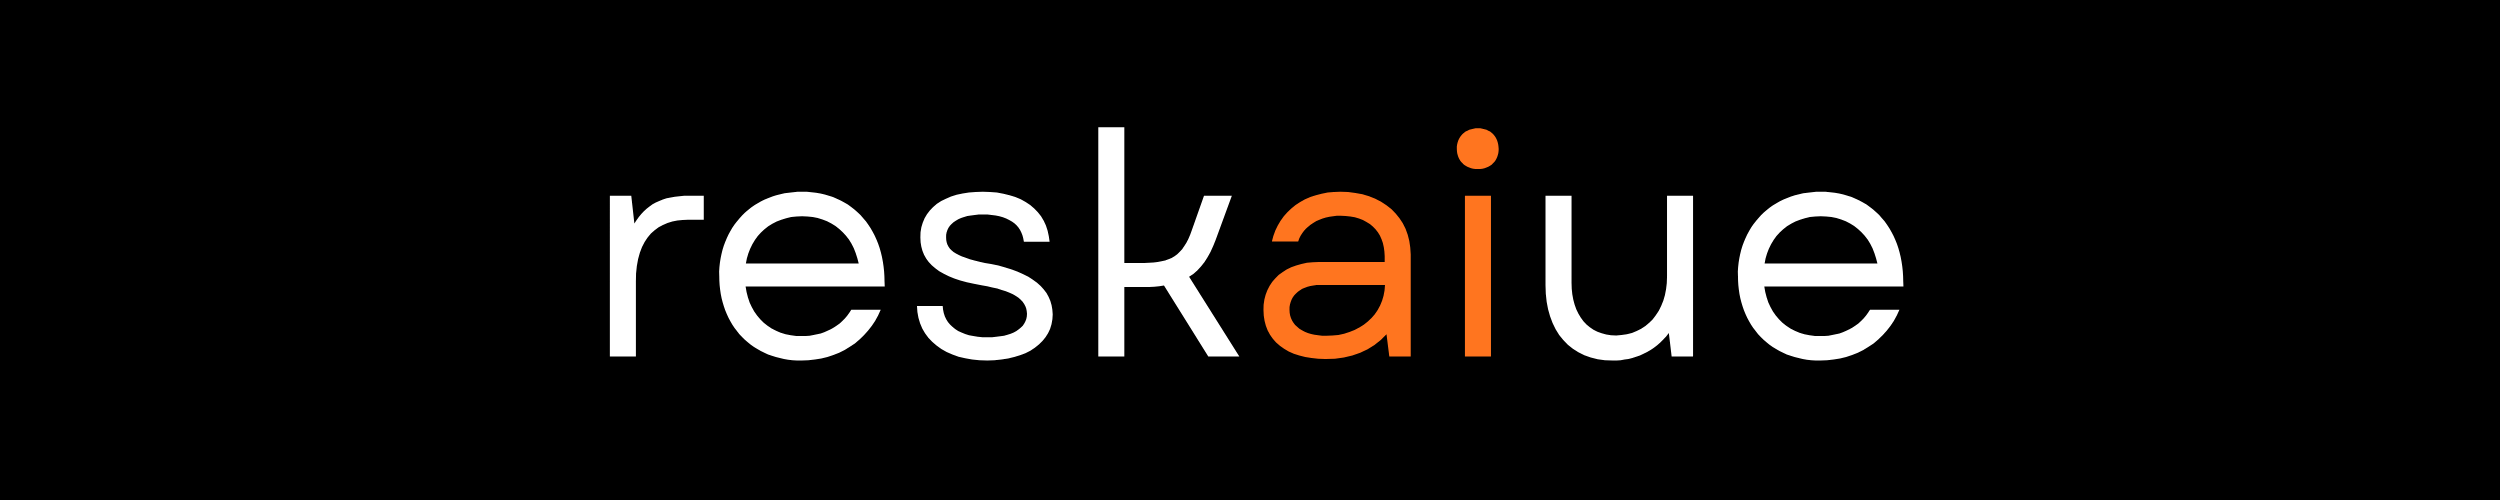

In [ ]:
# Dependencies

!pip install pandas matplotlib seaborn scipy tqdm
!pip install pyquaternion lxml
!pip install nuscenes-devkit

In [ ]:
# Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import json
from tqdm import tqdm

In [ ]:
# Helper Functions

def dataset_summary(df, name):
    print(f"\n===== {name} SUMMARY =====")

    # Dimensionality
    print("Shape (rows, columns):", df.shape)

    # Check if DataFrame is empty or has no columns before proceeding with detailed statistics
    if df.empty or df.columns.empty:
        print("DataFrame is empty or has no columns. Skipping detailed statistics.")
        return

    # Missing values
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print("\nMissing Values:")
    print(missing if len(missing) > 0 else "No missing values")

    # Descriptive statistics
    print("\nDescriptive Statistics:")
    display(df.describe(include='all').transpose())

def plot_distributions(df, numeric_cols, title):
    for col in numeric_cols:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True)
        plt.title(f"{title} - {col}")
        plt.show()

def detect_outliers_zscore(df, col, threshold=3):
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    return np.where(z_scores > threshold)[0]

In [ ]:
# NCLT Audit

import os # Ensure os is imported
import pandas as pd # Ensure pandas is imported

nclt_path = "/content/NCLT"

gps_files = []
nclt_df = pd.DataFrame() # Initialize empty DataFrame

if os.path.exists(nclt_path) and os.listdir(nclt_path):
    for root, _, files in os.walk(nclt_path):
        for f in files:
            if "gps" in f.lower() and f.endswith(".csv"):
                gps_files.append(os.path.join(root, f))

    gps_df_list = []
    for f in gps_files[:10]:
        try:
            df = pd.read_csv(f)
            gps_df_list.append(df)
        except Exception as e:
            print(f"Could not read NCLT GPS file {f}: {e}")

    if gps_df_list:
        nclt_df = pd.concat(gps_df_list, ignore_index=True)
    else:
        print(f"No valid GPS files found in {nclt_path}.")
else:
    print(f"NCLT dataset directory not found or is empty at {nclt_path}. Skipping NCLT audit.")

dataset_summary(nclt_df, "NCLT GPS Combined")

if not nclt_df.empty:
    for col in nclt_df.select_dtypes(include=np.number).columns:
        print(col, "outliers:", len(detect_outliers_zscore(nclt_df, col)))
else:
    print("NCLT DataFrame is empty, skipping outlier detection.")

In [ ]:
# WAYMO Open Audit

import tensorflow as tf
import os # Ensure os is imported
import pandas as pd # Ensure pandas is imported

def parse_tfrecord(file):
    dataset = tf.data.TFRecordDataset(file)
    return [len(list(dataset))]

waymo_path = "/content/waymo"
waymo_df = pd.DataFrame(columns=["file", "num_records"]) # Initialize empty DataFrame with expected columns

if os.path.exists(waymo_path) and os.listdir(waymo_path):
    waymo_files = []
    for root, _, files in os.walk(waymo_path):
        for f in files:
            if f.endswith(".tfrecord"):
                waymo_files.append(os.path.join(root, f))

    if waymo_files:
        records_list = []
        for f in waymo_files[:20]: # Limit to 20 files for efficiency
            try:
                dataset = tf.data.TFRecordDataset(f)
                records_list.append({"file": f, "num_records": len(list(dataset))})
            except Exception as e:
                print(f"Error reading TFRecord file {f}: {e}")
        if records_list:
            waymo_df = pd.DataFrame(records_list)
    else:
        print(f"No .tfrecord files found in {waymo_path}.")
else:
    print(f"Waymo dataset directory not found or is empty at {waymo_path}. Skipping Waymo audit.")

dataset_summary(waymo_df, "Waymo TFRecord Summary")


In [ ]:
# Argoverse 2 Audit

import json # Ensure json is imported
import os # Ensure os is imported
import pandas as pd # Ensure pandas is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting
import seaborn as sns # Ensure seaborn is imported for plotting

argo_path = "/content/argoverse2"
argo_df = pd.DataFrame(columns=["file", "keys", "size"]) # Initialize empty DataFrame with expected columns

if os.path.exists(argo_path) and os.listdir(argo_path):
    json_files = []
    for root, _, files in os.walk(argo_path):
        for f in files:
            if f.endswith(".json"):
                json_files.append(os.path.join(root, f))

    records = []
    for f in json_files[:50]: # Limit to 50 files for efficiency
        try:
            with open(f) as file:
                data = json.load(file)
                records.append({
                    "file": f,
                    "keys": len(data.keys()) if isinstance(data, dict) else 0,
                    "size": len(str(data))
                })
        except Exception as e:
            print(f"Error reading Argoverse 2 JSON file {f}: {e}")

    if records:
        argo_df = pd.DataFrame(records)
    else:
        print(f"No JSON files processed or found valid records in {argo_path}.")
else:
    print(f"Argoverse 2 dataset directory not found or is empty at {argo_path}. Skipping Argoverse 2 audit.")

dataset_summary(argo_df, "Argoverse 2 JSON Metadata")
if not argo_df.empty:
    plot_distributions(argo_df, ["keys", "size"], "Argoverse 2")
else:
    print("Argoverse 2 DataFrame is empty, skipping distribution plots.")


In [ ]:
# Terramobilita/iQmulus Audit

import os # Ensure os is imported
import pandas as pd # Ensure pandas is imported

iqmulus_path = "/content/iqmulus"

csv_files = []
iqmulus_df = pd.DataFrame() # Initialize empty DataFrame

if os.path.exists(iqmulus_path) and os.listdir(iqmulus_path):
    for root, _, files in os.walk(iqmulus_path):
        for f in files:
            if f.endswith(".csv"):
                csv_files.append(os.path.join(root, f))

    dfs = []
    for f in csv_files[:10]: # Limit to 10 files for efficiency
        try:
            dfs.append(pd.read_csv(f))
        except Exception as e:
            print(f"Error reading iQmulus/Terramobilita CSV file {f}: {e}")

    if dfs:
        iqmulus_df = pd.concat(dfs, ignore_index=True)
    else:
        print(f"No valid CSV files found in {iqmulus_path}.")
else:
    print(f"IQMulus/Terramobilita dataset directory not found or is empty at {iqmulus_path}. Skipping audit.")

dataset_summary(iqmulus_df, "IQMulus/Terramobilita")


In [ ]:
import pandas as pd

# Summary Table

nclt_df = pd.DataFrame()
waymo_df = pd.DataFrame(columns=["file", "num_records"])
argo_df = pd.DataFrame(columns=["file", "keys", "size"])
iqmulus_df = pd.DataFrame()

summary_table = pd.DataFrame({
    "Dataset": ["nuScenes", "NCLT", "Waymo", "Argoverse2", "IQMulus"],
    "Rows": [
        0,
        len(nclt_df),
        len(waymo_df),
        len(argo_df),
        len(iqmulus_df)
    ],
    "Features": [
        0,
        nclt_df.shape[1],
        waymo_df.shape[1],
        argo_df.shape[1],
        iqmulus_df.shape[1]
    ]
})

display(summary_table)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x='Dataset', y='Rows', data=summary_table, ax=ax[0], palette='viridis')
ax[0].set_title('Number of Rows per Dataset')
ax[0].set_ylabel('Number of Rows')
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Dataset', y='Features', data=summary_table, ax=ax[1], palette='plasma')
ax[1].set_title('Number of Features per Dataset')
ax[1].set_ylabel('Number of Features')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

As mentioned previously, the NCLT, Waymo, Argoverse2, and IQMulus datasets are not considered tabular at this point because their respective directories were not found or are empty, resulting in empty DataFrames. Therefore, no further visualization can be performed on them until data is loaded.